In [ ]:
# Nhập thư viện và file excel
import pandas as pd
import numpy as np
df = pd.read_excel('Raw data (use this for coding).xlsx', sheet_name='Fixed_adjustclosingprice')
df = df.drop("STT", axis=1)

In [ ]:
# Kiểm tra tổng số ô trống trong từng cột, nếu phát hiện, dùng phương pháp Forward Fill
print(df.isnull().sum())
if df.isnull().values.any():
    df = df.ffill()
    print("có missing values và đã fix")
else:
    print("Dữ liệu ổn, không có missing values")

# Sắp xếp lại ngày từ cũ nhất đến mới nhất để tính Return
df['Ngày'] = pd.to_datetime(df['Ngày'], dayfirst=True)
df = df.sort_values('Ngày').reset_index(drop=True)
print("")
print(df[['Ngày']].head())
print(df['Ngày'].min(), df['Ngày'].max())

Ngày                          0
FPT                           0
HPG                           0
SSI                           0
VCB                           0
MWG                           0
VHM                           0
VNINDEX                       0
Vietnam 1Y Bond Yield (%)     0
Vietnam 2Y Bond Yield (%)     0
Vietnam 3Y Bond Yield (%)     0
Vietnam 10Y Bond Yield (%)    0
dtype: int64
Dữ liệu ổn, không có missing values

        Ngày
0 2025-06-06
1 2025-06-13
2 2025-06-20
3 2025-06-27
4 2025-07-04
2025-06-06 00:00:00 2025-12-31 00:00:00


In [ ]:
### XỬ LÍ DỮ LIỆU
# 1. Chuẩn hóa định dạng số
price_cols = ['FPT', 'HPG', 'SSI', 'VCB', 'MWG', 'VHM', 'VNINDEX']
df[price_cols] = df[price_cols].astype(float)
df[price_cols] = df[price_cols].apply(pd.to_numeric, errors='coerce')
yield_cols = ['Vietnam 1Y Bond Yield (%)', 'Vietnam 2Y Bond Yield (%)', 'Vietnam 3Y Bond Yield (%)', 'Vietnam 10Y Bond Yield (%)']
df[yield_cols] = df[yield_cols].apply(pd.to_numeric, errors='coerce')

# 2. Chuyển đổi lợi suất theo năm thành lợi suất theo tuần (Carry Return) và tính trung bình cho cả giai đoạn
maturities = ['1Y','2Y','3Y','10Y']
for m in maturities:
    col_name = f'Vietnam {m} Bond Yield (%)'
    df[f'Rf_{m}'] = (1 + df[col_name] / 100)**(1/52) - 1
avg_rf = df[[f'Rf_{m}' for m in maturities]].mean()
carry_return_table = df[['Ngày'] + [f'Rf_{m}' for m in maturities]].copy()
df.drop(columns=[f'Vietnam {m} Bond Yield (%)' for m in maturities],
        inplace=True)

# 3. In dữ liệu
print("\n    Định dạng dữ liệu    ")
print(df.dtypes)
print("\n     Data (First 5 rows)    ")
print(df.head())
print(f"\n    Average Weekly Risk-Free Rates:")
print(f"Rf_1Y  : {avg_rf['Rf_1Y']:.6f}")
print(f"Rf_2Y  : {avg_rf['Rf_2Y']:.6f}")
print(f"Rf_3Y  : {avg_rf['Rf_3Y']:.6f}")
print(f"Rf_10Y : {avg_rf['Rf_10Y']:.6f}")


    Định dạng dữ liệu    
Ngày       datetime64[ns]
FPT               float64
HPG               float64
SSI               float64
VCB               float64
MWG               float64
VHM               float64
VNINDEX           float64
Rf_1Y             float64
Rf_2Y             float64
Rf_3Y             float64
Rf_10Y            float64
dtype: object

     Data (First 5 rows)    
        Ngày       FPT      HPG      SSI      VCB      MWG      VHM  VNINDEX  \
0 2025-06-06   97460.0  19730.0  16370.0  37390.0  53950.0  76800.0  1329.89   
1 2025-06-13   98470.0  20000.0  16050.0  37190.0  56360.0  70000.0  1315.49   
2 2025-06-20   99070.0  20450.0  16640.0  37590.0  57160.0  71700.0  1349.35   
3 2025-06-27  100100.0  22850.0  17090.0  37450.0  58680.0  76000.0  1371.44   
4 2025-07-04  104530.0  23250.0  17960.0  38450.0  59130.0  76300.0  1386.97   

      Rf_1Y     Rf_2Y     Rf_3Y    Rf_10Y  
0  0.000434  0.000442  0.000454  0.000616  
1  0.000433  0.000441  0.000452  0.000619  
2  0

In [ ]:
### TÍNH TOÁN
# 1. Tính tỷ suất sinh lời tuần, Phương sai và Độ lệch chuẩn
tickers = ['FPT', 'HPG', 'SSI', 'VCB', 'MWG', 'VHM', 'VNINDEX']
returns_df = df[tickers].pct_change().dropna()
weekly_return_table = returns_df.copy()
weekly_return_table.insert(0, 'Ngày', df.loc[returns_df.index, 'Ngày'])
print("\n    Weekly Return (First 5 rows)    ")
print(weekly_return_table.head())

# 2. Tính các thông số thống kê
expected_returns = returns_df.mean()
variances = returns_df.var()
std_deviations = returns_df.std()
stats_summary = pd.DataFrame({
    'Expected return (E[r])': expected_returns,
    'Variance (sigma^2)': variances,
    'Std Deviation (sigma)': std_deviations
})
print("\n    Expected returns and volatility summary    ")
print(stats_summary)

# 3. Ma trận Hiệp phương sai và Tương quan
cov_matrix = returns_df.cov(ddof=0)
corr_matrix = returns_df.corr()

print("\n    Covariance matrix    ")
print(cov_matrix)
print("\n    Correlation matrix    ")
print(corr_matrix)


    Weekly Return (First 5 rows)    
        Ngày       FPT       HPG       SSI       VCB       MWG       VHM  \
1 2025-06-13  0.010363  0.013685 -0.019548 -0.005349  0.044671 -0.088542   
2 2025-06-20  0.006093  0.022500  0.036760  0.010756  0.014194  0.024286   
3 2025-06-27  0.010397  0.117359  0.027043 -0.003724  0.026592  0.059972   
4 2025-07-04  0.044256  0.017505  0.050907  0.026702  0.007669  0.003947   
5 2025-07-11  0.033483  0.118280  0.144766  0.060338  0.024015  0.127130   

    VNINDEX  
1 -0.010828  
2  0.025739  
3  0.016371  
4  0.011324  
5  0.051039  

    Expected returns and volatility summary    
         Expected return (E[r])  Variance (sigma^2)  Std Deviation (sigma)
FPT                    0.000686            0.002650               0.051482
HPG                    0.010902            0.002445               0.049450
SSI                    0.023001            0.005064               0.071165
VCB                    0.017573            0.008186               0.0904

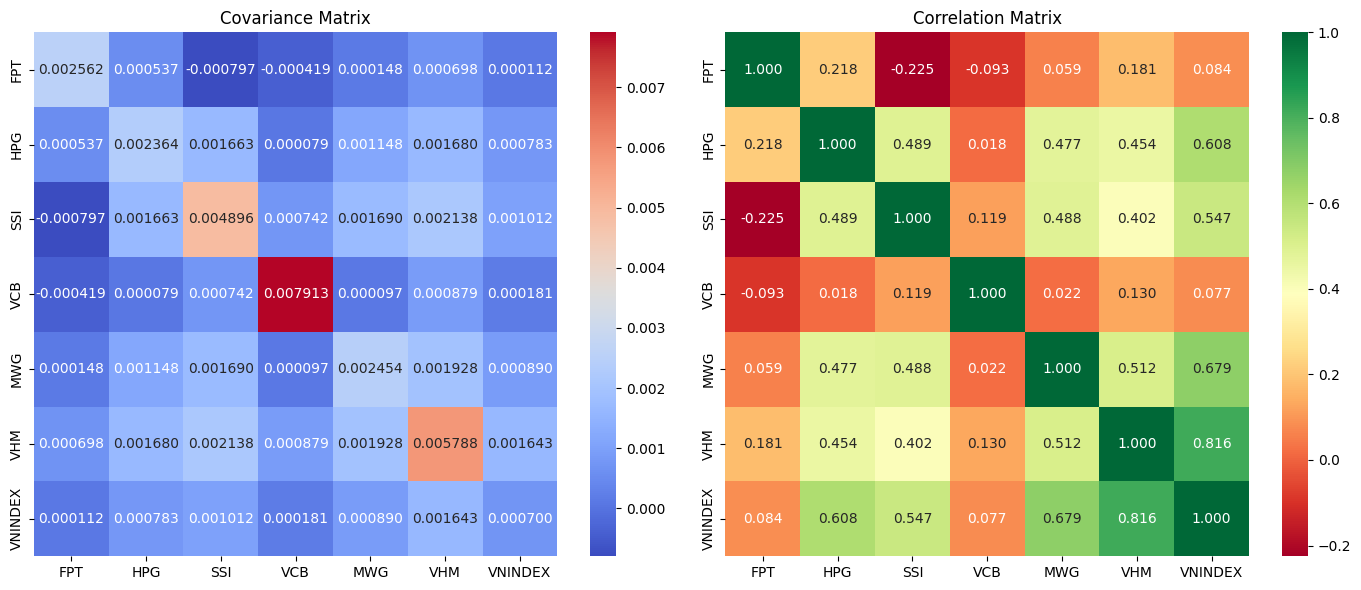

In [ ]:
### TRỰC QUAN HÓA
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(1, 2, figsize=(14,6))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".6f", ax=ax[0])
ax[0].set_title('Covariance Matrix')
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".3f", ax=ax[1])
ax[1].set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [17]:
### CONSTRUCTION OF EFFICIENT FRONTIER

# Helper functions
def portfolio_return(weights, expected_returns):
    return np.sum(expected_returns * weights) * 52 # Annualized return

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(52) # Annualized volatility

def sharpe_ratio(returns, volatility, risk_free_rate):
    return (returns - risk_free_rate) / volatility

# Function to simulate portfolios
def simulate_portfolios(num_portfolios, expected_returns, cov_matrix, risk_free_rate, short_selling_allowed=True):
    num_assets = len(expected_returns)
    results = np.zeros((3, num_portfolios)) # Returns, Volatility, Sharpe Ratio
    weights_record = []

    for i in range(num_portfolios):
        if short_selling_allowed:
            weights = np.random.rand(num_assets)
            weights /= np.sum(weights)
            # Allow negative weights for short selling
            weights = weights - 0.5 # Shift weights to allow negative values, ensuring they still sum to 1 after normalization
            weights = weights / np.sum(np.abs(weights)) # Normalize so abs sum to 1

        else:
            weights = np.random.rand(num_assets)
            weights /= np.sum(weights)

        port_return = portfolio_return(weights, expected_returns)
        port_volatility = portfolio_volatility(weights, cov_matrix)

        # Annualize risk-free rate for Sharpe Ratio calculation
        annual_risk_free_rate = (1 + risk_free_rate)**52 - 1

        results[0, i] = port_return
        results[1, i] = port_volatility
        results[2, i] = sharpe_ratio(port_return, port_volatility, annual_risk_free_rate)
        weights_record.append(weights)

    return results, weights_record

print("Helper functions and portfolio simulation function defined.")

Helper functions and portfolio simulation function defined.


In [ ]:
# 1. Simulate portfolios without short-selling
num_portfolios = 25000 # Increased for better resolution
risk_free_rate = avg_rf['Rf_1Y'] # Using the 1-year bond yield as the risk-free rate

# Get tickers from expected_returns index
tickers = expected_returns.index.tolist()

results_no_short_selling, weights_no_short_selling = simulate_portfolios(
    num_portfolios,
    expected_returns,
    cov_matrix,
    risk_free_rate,
    short_selling_allowed=False
)

# Find the portfolio with the highest Sharpe Ratio (Optimal Risky Portfolio)
max_sharpe_idx_no_short_selling = np.argmax(results_no_short_selling[2])
optimal_risky_return_no_short_selling = results_no_short_selling[0, max_sharpe_idx_no_short_selling]
optimal_risky_volatility_no_short_selling = results_no_short_selling[1, max_sharpe_idx_no_short_selling]
optimal_risky_weights_no_short_selling = weights_no_short_selling[max_sharpe_idx_no_short_selling]

# Find the Global Minimum Variance Portfolio (GMVP)
min_volatility_idx_no_short_selling = np.argmin(results_no_short_selling[1])
gmvp_return_no_short_selling = results_no_short_selling[0, min_volatility_idx_no_short_selling]
gmvp_volatility_no_short_selling = results_no_short_selling[1, min_volatility_idx_no_short_selling]
gmvp_weights_no_short_selling = weights_no_short_selling[min_volatility_idx_no_short_selling]

print("Optimal Risky Portfolio (No Short Selling):")
print(f"  Annualized Return: {optimal_risky_return_no_short_selling:.4f}")
print(f"  Annualized Volatility: {optimal_risky_volatility_no_short_selling:.4f}")
print(f"  Sharpe Ratio: {results_no_short_selling[2, max_sharpe_idx_no_short_selling]:.4f}")
print(f"  Weights: {pd.Series(optimal_risky_weights_no_short_selling, index=tickers).to_dict()}")

print("\nGlobal Minimum Variance Portfolio (No Short Selling):")
print(f"  Annualized Return: {gmvp_return_no_short_selling:.4f}")
print(f"  Annualized Volatility: {gmvp_volatility_no_short_selling:.4f}")
print(f"  Sharpe Ratio: {results_no_short_selling[2, min_volatility_idx_no_short_selling]:.4f}")
print(f"  Weights: {pd.Series(gmvp_weights_no_short_selling, index=tickers).to_dict()}")

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(results_no_short_selling[1,:], results_no_short_selling[0,:], c=results_no_short_selling[2,:], cmap='viridis', marker='o', s=10, alpha=0.6)
plt.colorbar(label='Sharpe Ratio')

# Plot Optimal Risky Portfolio
plt.scatter(optimal_risky_volatility_no_short_selling, optimal_risky_return_no_short_selling, marker='*', color='red', s=500, label='Optimal Risky Portfolio (No Short Selling)')

# Plot GMVP
plt.scatter(gmvp_volatility_no_short_selling, gmvp_return_no_short_selling, marker='X', color='purple', s=500, label='GMVP (No Short Selling)')

# Plot Capital Market Line (CML) for no short selling
# Annualized risk-free rate
annual_risk_free_rate = (1 + risk_free_rate)**52 - 1
cml_x_no_short_selling = np.linspace(0, optimal_risky_volatility_no_short_selling * 1.5, 100)
cml_y_no_short_selling = annual_risk_free_rate + (optimal_risky_return_no_short_selling - annual_risk_free_rate) / optimal_risky_volatility_no_short_selling * cml_x_no_short_selling
plt.plot(cml_x_no_short_selling, cml_y_no_short_selling, color='green', linestyle='--', label='Capital Market Line (No Short Selling)')

plt.title('Efficient Frontier with No Short Selling Allowed')
plt.xlabel('Annualized Volatility (Standard Deviation)')
plt.ylabel('Annualized Expected Return')
plt.legend()
plt.grid(True)
plt.show()

Next, let's analyze the efficient frontier when short selling is allowed. I will follow the same steps: simulate portfolios, identify the optimal risky portfolio and GMVP, and then plot the results to compare with the 'no short selling' scenario.

In [ ]:
# 2. Simulate portfolios with short-selling allowed

results_short_selling, weights_short_selling = simulate_portfolios(
    num_portfolios,
    expected_returns,
    cov_matrix,
    risk_free_rate,
    short_selling_allowed=True
)

# Find the portfolio with the highest Sharpe Ratio (Optimal Risky Portfolio)
max_sharpe_idx_short_selling = np.argmax(results_short_selling[2])
optimal_risky_return_short_selling = results_short_selling[0, max_sharpe_idx_short_selling]
optimal_risky_volatility_short_selling = results_short_selling[1, max_sharpe_idx_short_selling]
optimal_risky_weights_short_selling = weights_short_selling[max_sharpe_idx_short_selling]

# Find the Global Minimum Variance Portfolio (GMVP)
min_volatility_idx_short_selling = np.argmin(results_short_selling[1])
gmvp_return_short_selling = results_short_selling[0, min_volatility_idx_short_selling]
gmvp_volatility_short_selling = results_short_selling[1, min_volatility_idx_short_selling]
gmvp_weights_short_selling = weights_short_selling[min_volatility_idx_short_selling]

print("Optimal Risky Portfolio (Short Selling Allowed):")
print(f"  Annualized Return: {optimal_risky_return_short_selling:.4f}")
print(f"  Annualized Volatility: {optimal_risky_volatility_short_selling:.4f}")
print(f"  Sharpe Ratio: {results_short_selling[2, max_sharpe_idx_short_selling]:.4f}")
print(f"  Weights: {pd.Series(optimal_risky_weights_short_selling, index=tickers).to_dict()}")

print("\nGlobal Minimum Variance Portfolio (Short Selling Allowed):")
print(f"  Annualized Return: {gmvp_return_short_selling:.4f}")
print(f"  Annualized Volatility: {gmvp_volatility_short_selling:.4f}")
print(f"  Sharpe Ratio: {results_short_selling[2, min_volatility_idx_short_selling]:.4f}")
print(f"  Weights: {pd.Series(gmvp_weights_short_selling, index=tickers).to_dict()}")

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(results_short_selling[1,:], results_short_selling[0,:], c=results_short_selling[2,:], cmap='magma', marker='o', s=10, alpha=0.6)
plt.colorbar(label='Sharpe Ratio')

# Plot Optimal Risky Portfolio
plt.scatter(optimal_risky_volatility_short_selling, optimal_risky_return_short_selling, marker='*', color='red', s=500, label='Optimal Risky Portfolio (Short Selling Allowed)')

# Plot GMVP
plt.scatter(gmvp_volatility_short_selling, gmvp_return_short_selling, marker='X', color='purple', s=500, label='GMVP (Short Selling Allowed)')

# Plot Capital Market Line (CML) for short selling
cml_x_short_selling = np.linspace(0, optimal_risky_volatility_short_selling * 1.5, 100)
cml_y_short_selling = annual_risk_free_rate + (optimal_risky_return_short_selling - annual_risk_free_rate) / optimal_risky_volatility_short_selling * cml_x_short_selling
plt.plot(cml_x_short_selling, cml_y_short_selling, color='green', linestyle='--', label='Capital Market Line (Short Selling Allowed)')

plt.title('Efficient Frontier with Short Selling Allowed')
plt.xlabel('Annualized Volatility (Standard Deviation)')
plt.ylabel('Annualized Expected Return')
plt.legend()
plt.grid(True)
plt.show()

Now, let's combine both efficient frontiers in a single plot for comparison.

In [ ]:
plt.figure(figsize=(14, 10))

# Plot Efficient Frontier without short-selling
plt.scatter(results_no_short_selling[1,:], results_no_short_selling[0,:], c=results_no_short_selling[2,:], cmap='viridis', marker='o', s=10, alpha=0.6, label='Portfolios (No Short Selling)')
plt.colorbar(label='Sharpe Ratio (No Short Selling)')
plt.scatter(optimal_risky_volatility_no_short_selling, optimal_risky_return_no_short_selling, marker='*', color='red', s=500, label='Optimal Risky Portfolio (No Short Selling)')
plt.scatter(gmvp_volatility_no_short_selling, gmvp_return_no_short_selling, marker='X', color='purple', s=500, label='GMVP (No Short Selling)')
plt.plot(cml_x_no_short_selling, cml_y_no_short_selling, color='green', linestyle='--', label='CML (No Short Selling)')

# Plot Efficient Frontier with short-selling
plt.scatter(results_short_selling[1,:], results_short_selling[0,:], c=results_short_selling[2,:], cmap='magma', marker='^', s=10, alpha=0.6, label='Portfolios (Short Selling Allowed)')
plt.colorbar(label='Sharpe Ratio (Short Selling Allowed)')
plt.scatter(optimal_risky_volatility_short_selling, optimal_risky_return_short_selling, marker='*', color='darkred', s=500, label='Optimal Risky Portfolio (Short Selling Allowed)')
plt.scatter(gmvp_volatility_short_selling, gmvp_return_short_selling, marker='X', color='darkmagenta', s=500, label='GMVP (Short Selling Allowed)')
plt.plot(cml_x_short_selling, cml_y_short_selling, color='darkgreen', linestyle='--', label='CML (Short Selling Allowed)')

plt.title('Comparison of Efficient Frontiers with and without Short Selling')
plt.xlabel('Annualized Volatility (Standard Deviation)')
plt.ylabel('Annualized Expected Return')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()